In [ ]:
import numpy, pandas, matplotlib                                                                                                                                                                                                                                                      
print("ok") 

In [8]:
from opcua import Client

client = Client("opc.tcp://localhost:49320")
client.connect()
print("Tilkoblet!")

# Test én tag
node = client.get_node("ns=2;s=Rigg1.PLS1.slider")
print("slider verdi:", node.get_value())

client.disconnect()

Requested session timeout to be 3600000ms, got 60000ms instead


Tilkoblet!
slider verdi: 60


In [ ]:
import asyncio
import csv
from datetime import datetime
from asyncua import Client
import nest_asyncio
nest_asyncio.apply()

filnavn = "autotuning"
CSV_FIL = f"{filnavn}.csv"
OPC_URL = "opc.tcp://localhost:49320"

INTERVALL_SEK = 0.05

TAGS = {
    "pådrag":     "ns=2;s=Rigg1.PLS1.flow_glob",
    "tank":       "ns=2;s=Rigg1.PLS1.TankNivå",
}

async def main():
    async with Client(url=OPC_URL) as client:
        print(f"Koblet til {OPC_URL}")

        noder = {navn: client.get_node(adresse) for navn, adresse in TAGS.items()}

        with open(CSV_FIL, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["Tidsstempel"] + list(TAGS.keys()))

            for _ in range(100000):  # Endre til while True for evig kjøring
                tidsstempel = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                verdier = []

                for navn, node in noder.items():
                    try:
                        verdi = await node.read_value()
                        verdier.append(verdi)
                    except Exception as e:
                        print(f"Feil ved lesing av '{navn}': {e}")
                        verdier.append(None)

                writer.writerow([tidsstempel] + verdier)
                f.flush()
                print(f"[{tidsstempel}] {dict(zip(TAGS.keys(), verdier))}")
                await asyncio.sleep(INTERVALL_SEK)

    print(f"Ferdig! Data lagret i '{CSV_FIL}'")

asyncio.run(main())

Requested session timeout to be 3600000ms, got 60000ms instead


Koblet til opc.tcp://localhost:49320
[2026-04-28 17:12:37] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:37] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 40, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 

Future for request id 1897 is already done


[2026-04-28 17:14:12] {'pådrag': 39, 'tank': 51.0}
[2026-04-28 17:14:12] {'pådrag': 39, 'tank': 51.0}


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

filnavn   = "40til50_ventil_tau62_noisy"
CSV_FIL   = f"{filnavn}.csv"

start_tid = 400
slutt_tid = 1000
step_tid  = 437
tau       = 62

# ---------- LAST DATA ----------
df = pd.read_csv(CSV_FIL)
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()

df_plot = df[(df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)].copy().reset_index(drop=True)
if df_plot.empty:
    raise ValueError(f"Fant ingen data i tidsvinduet {start_tid} til {slutt_tid} sekunder.")

window = 7
df_plot["tank_smooth"] = df_plot["tank"].rolling(window=window, center=True, min_periods=1).mean()

tid_relativ      = df_plot["tid_s"] - start_tid
step_tid_relativ = step_tid - start_tid
tau_tid_relativ  = step_tid_relativ + tau

start_verdi = df_plot.loc[df_plot["tid_s"] <  step_tid, "tank_smooth"].iloc[-1]
slutt_verdi = df_plot["tank_smooth"].iloc[-1]
tau_632     = start_verdi + 0.632 * (slutt_verdi - start_verdi)

# ---------- STIL (matcher autotuning-plot) ----------
mpl.rcParams.update({
    "font.family":       "serif",
    "font.size":         18,
    "axes.titlesize":    20,
    "axes.labelsize":    20,
    "legend.fontsize":   12,
    "xtick.labelsize":   18,
    "ytick.labelsize":   18,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":   2.0,
})

GRONN = "tab:green"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

# === Panel 1: tanknivå ===
ax1.plot(tid_relativ, df_plot["tank"],        color="tab:blue", alpha=0.30, lw=1.2, label="Tanknivå (rå)")
ax1.plot(tid_relativ, df_plot["tank_smooth"], color="tab:blue", lw=2.6,            label="Tanknivå (glattet)")
ax1.axvline(tau_tid_relativ, color="tab:red", lw=1.5, ls="--", alpha=0.8,
            label=fr"Tidskonstant $\tau = {tau}\,$s")
ax1.axhline(tau_632,         color="tab:red", lw=1.5, ls=":",  alpha=0.8,
            label="63.2 % av endringen")
ax1.set_ylabel("Tanknivå [%]")
ax1.set_title(f"Sprang fra 40 % til 50 %", weight="bold")
ax1.legend(loc="lower right", ncol=2, framealpha=0.9)

# === Panel 2: pådrag ===
ax2.plot(tid_relativ, df_plot["pådrag"], color=GRONN, lw=2.2, label="Pådrag")
ax2.set_xlabel("Tid [s]")
ax2.set_ylabel("Pådrag [%]")
ax2.legend(loc="upper right", framealpha=0.9)
ax2.margins(x=0)

plt.tight_layout()
plt.savefig(f"{filnavn}_kurve.pdf", bbox_inches="tight")
plt.savefig(f"{filnavn}_kurve.png", bbox_inches="tight", dpi=300)
plt.show()


Analyserer autotuning fra t=0s til t=500s
Data points: 899
Detektert relay ON nivå: 49.0
Detektert relay OFF nivå: 29.0
Detektert relay amplitude (fRelayD): 10.0
Detektert nominalt pådrag (fNomPådrag): 38.0

Funnet 17 zero-crossings

Gyldighetanalyse:
Totale halvperioder: 16
Gyldige halvperioder: 10
Minimum påkrevd (iMinHalfCycles): 6

Detaljer om hver halvperiode:
  Halvperiode 1: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 2: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=1.000s ✗ UGYLDIG
  Halvperiode 3: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 4: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 5: MAX=51.0000, MIN=46.0000, Amplitude=2.5000, dT=16.000s ✓ GYLDIG
  Halvperiode 6: MAX=54.0000, MIN=50.0000, Amplitude=2.0000, dT=8.000s ✓ GYLDIG
  Halvperiode 7: MAX=50.0000, MIN=49.0000, Amplitude=0.5000, dT=1.000s ✓ GYLDIG
  Halvperiode 8: MAX=50.0000, MIN=46.0000, Amplitude=2.0000, dT=8.0

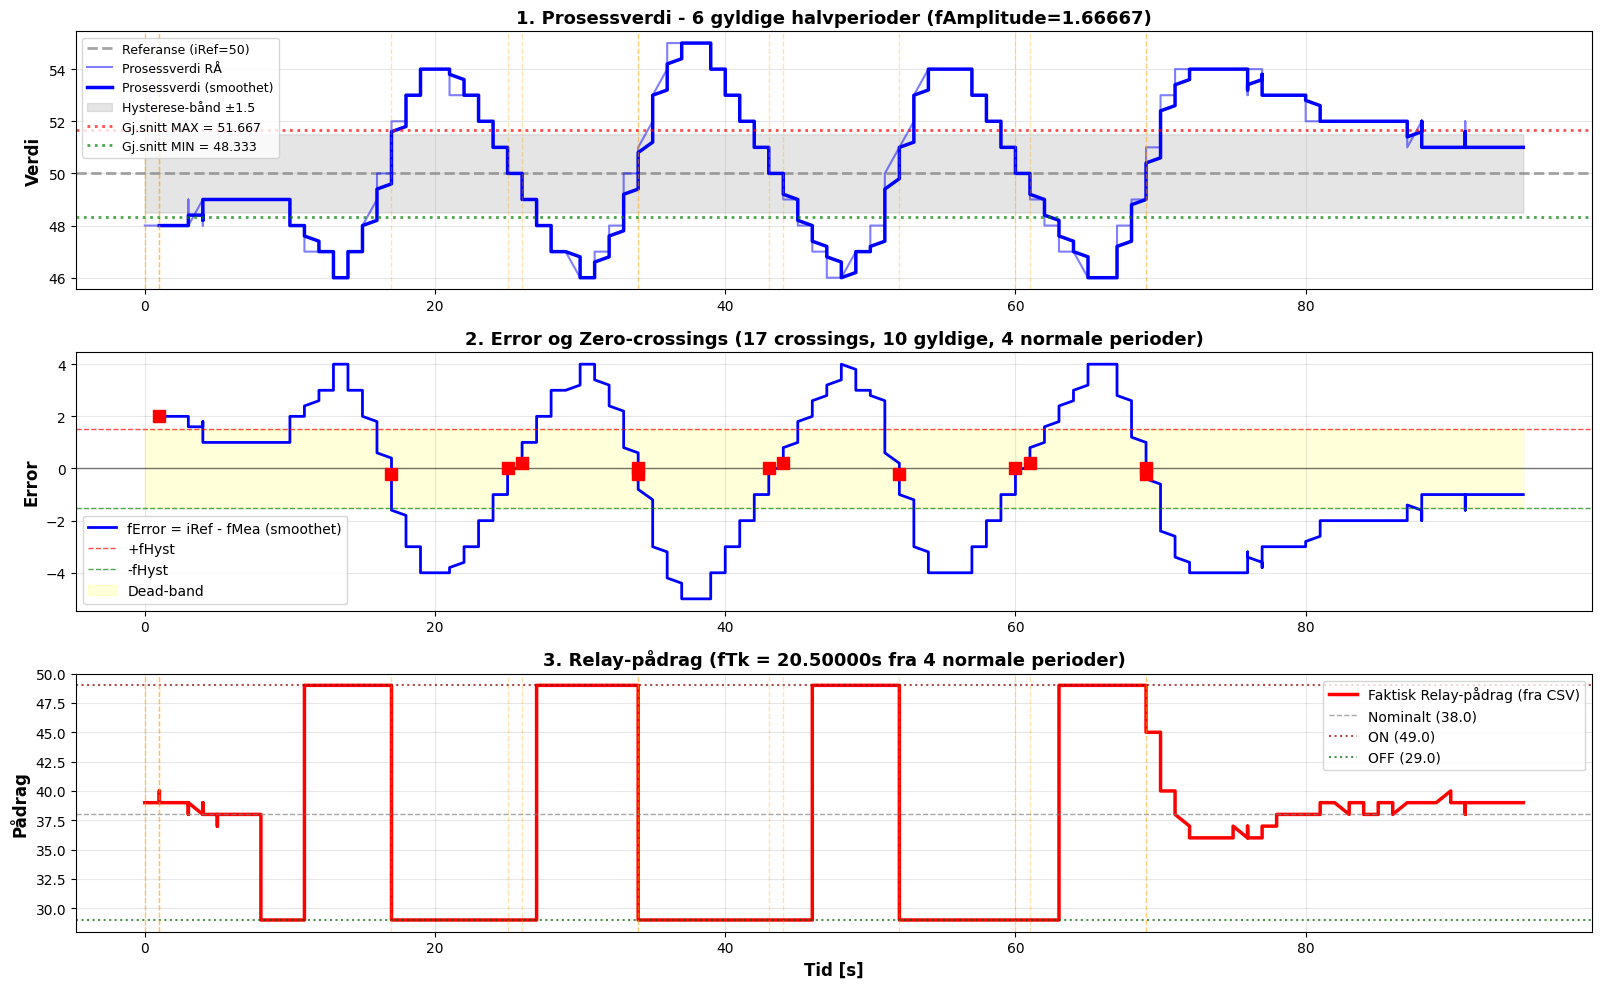

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

df = pd.read_csv(f"{CSV_FIL}")
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()
df["tank_smooth"] = df["tank"].rolling(window=5).mean()

# INNSTILLINGER FOR AUTOTUNING
start_tid = 0 # Start tid - hvor autotuning begynner
slutt_tid = 500  # Slutt tid - hvor autotuning slutter
iRef = 50          # Referanse verdi
fHyst = 1.5        # Hysterese
iMinHalfCycles = 6  # KRITISK: Minimum gyldige halvperioder (fra din PLC)
min_period_threshold = 2.0  # Minimum periode for å være "normal" (fjerner anomalier)

# Filtrer til tidsintervallet
df_plot = df[(df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)].copy().reset_index(drop=True)

print(f"Analyserer autotuning fra t={start_tid}s til t={slutt_tid}s")
print(f"Data points: {len(df_plot)}")

# Finn de faktiske ON/OFF nivåer fra pådraget
padrag_values = df_plot["pådrag"].values
padrag_sorted = np.sort(padrag_values)
fNomPådrag_auto = padrag_sorted[len(padrag_sorted)//2]  # Midtpunkt
fRelayD_auto = (padrag_sorted[-1] - padrag_sorted[0]) / 2  # Halve differansen

fRelayD = fRelayD_auto
fNomPådrag = fNomPådrag_auto

print(f"Detektert relay ON nivå: {padrag_sorted[-1]:.1f}")
print(f"Detektert relay OFF nivå: {padrag_sorted[0]:.1f}")
print(f"Detektert relay amplitude (fRelayD): {fRelayD:.1f}")
print(f"Detektert nominalt pådrag (fNomPådrag): {fNomPådrag:.1f}")

# ===== EKSAKT SAMME LOGIKK SOM PLC =====
# 1. Beregn error (bruker smoothet for stabilitet)
df_plot["fError"] = iRef - df_plot["tank_smooth"]

# 2. Finn zero-crossings (hvor error skifter fortegn)
df_plot["error_sign_change"] = np.sign(df_plot["fError"]) != np.sign(df_plot["fError"].shift(1))

# Finn ALLE zero-crossing-indekser
zero_crossing_indices = df_plot[df_plot["error_sign_change"]].index.tolist()

print(f"\nFunnet {len(zero_crossing_indices)} zero-crossings")

# 3. For hver halvperiode (mellom zero-crossings), finn MAX og MIN av RÅ DATA
if len(zero_crossing_indices) >= 2:
    # Samle alle MAX/MIN for hver halvperiode
    all_max = []
    all_min = []
    all_periods = []
    all_valid = []  # Track which ones are valid
    
    for i in range(len(zero_crossing_indices) - 1):
        idx_start = zero_crossing_indices[i]
        idx_end = zero_crossing_indices[i + 1]
        
        # Hent RÅ DATA i denne halvperioden
        segment = df_plot["tank"].iloc[idx_start:idx_end+1]
        
        if len(segment) > 0:
            peak_high = segment.max()
            peak_low = segment.min()
            
            all_max.append(peak_high)
            all_min.append(peak_low)
            
            # Periode = tid mellom to zero-crossings
            dt = df_plot["tid_s"].iloc[idx_end] - df_plot["tid_s"].iloc[idx_start]
            all_periods.append(dt)
            
            # KRITISK: En halvperiode er VALID hvis:
            # 1. Det er faktisk oscillasjon (MAX > MIN)
            # 2. Perioden er ikke null
            is_valid = (peak_high > peak_low) and (dt > 0.1)  # Minimum 0.1s periode
            all_valid.append(is_valid)
    
    if len(all_max) > 0:
        # KRITISK: Filtrer til bare GYLDIGE halvperioder
        valid_indices = [i for i, v in enumerate(all_valid) if v]
        
        print(f"\nGyldighetanalyse:")
        print(f"Totale halvperioder: {len(all_max)}")
        print(f"Gyldige halvperioder: {len(valid_indices)}")
        print(f"Minimum påkrevd (iMinHalfCycles): {iMinHalfCycles}")
        
        print(f"\nDetaljer om hver halvperiode:")
        for i in range(len(all_max)):
            amplitude_i = (all_max[i] - all_min[i]) / 2.0
            status = "✓ GYLDIG" if all_valid[i] else "✗ UGYLDIG"
            print(f"  Halvperiode {i+1}: MAX={all_max[i]:.4f}, MIN={all_min[i]:.4f}, Amplitude={amplitude_i:.4f}, dT={all_periods[i]:.3f}s {status}")
        
        # Bruk kun de første N gyldige halvperiodene (som PLC gjør)
        if len(valid_indices) >= iMinHalfCycles:
            # Velg de første iMinHalfCycles gyldige halvperioder
            selected_indices = valid_indices[:iMinHalfCycles]
            
            print(f"\nValgt halvperioder #{selected_indices} (de første {iMinHalfCycles} gyldige)")
            
            # Gjennomsnitt av amplitude fra ALLE de 6 gyldige halvperiodene
            selected_max = [all_max[i] for i in selected_indices]
            selected_min = [all_min[i] for i in selected_indices]
            selected_periods = [all_periods[i] for i in selected_indices]
            
            fPeakHigh = np.mean(selected_max)
            fPeakLow = np.mean(selected_min)
            fAmplitude = (fPeakHigh - fPeakLow) / 2.0
            
            # KRITISK FILTER: Fjern perioder som er anomalier (for korte)
            # Anomali-halvperioder har dT < 2.0s og påvirker gjennomsnittperioden
            good_periods = [p for p in selected_periods if p >= min_period_threshold]
            
            if len(good_periods) >= 4:  # Minimum 4 "normale" perioder
                fHalfPeriod = np.mean(good_periods)  # GJENNOMSNITT av kun de "normale"
                print(f"✓ Filtrert: Fjernet perioder < {min_period_threshold}s (anomalier)")
                print(f"  Normale perioder: {good_periods}")
            else:
                # Hvis for få normale perioder, bruk alle 6
                fHalfPeriod = np.mean(selected_periods)
                print(f"  Bruker alle perioder (ikke nok >={min_period_threshold}s)")
                print(f"  Perioder: {selected_periods}")
            
            fTk = fHalfPeriod * 2.0
            fHalfPeriod_last = selected_periods[-1]  # For informasjon
            
            # Kritisk forsterkning
            fKk = (4.0 * fRelayD) / (3.14159 * fAmplitude) if fAmplitude > 0 else 0
            
            print("\n" + "=" * 70)
            print("AUTOTUNING ANALYSE - EKSAKT SLIK DIN PLC GJØR DET")
            print("=" * 70)
            print(f"\nAmplitude beregnet fra ALLE 6 halvperioder:")
            print(f"fPeakHigh (gjennomsnitt): {fPeakHigh:.5f}")
            print(f"fPeakLow (gjennomsnitt):  {fPeakLow:.5f}")
            print(f"fAmplitude = (H-L)/2:     {fAmplitude:.5f}")
            print(f"\nPeriode beregnet fra NORMALE halvperioder (>{min_period_threshold}s):")
            print(f"fHalfPeriod (gjennomsnitt): {fHalfPeriod:.5f} s  ← BRUKT FOR BEREGNING")
            print(f"fTk = 2 × fHalfPeriod:    {fTk:.5f} s")
            print(f"\nKritisk forsterkning:")
            print(f"fKk = (4.0 * {fRelayD:.1f}) / (3.14159 * {fAmplitude:.5f}) = {fKk:.6f}")
            print("=" * 70)
            
            # ===== PLC FORMLER - EKSAKT IMPLEMENTERING =====
            print("\n" + "=" * 70)
            print("PID PARAMETERE - EKSAKT SAMME FORMLER SOM DIN PLC")
            print("=" * 70)
            
            # PI (Tyreus-Luppen)
            fKp_PI = fKk / 3.2
            fKi_PI = fKp_PI / (2.2 * fTk) if fTk > 0 else 0
            
            # PID (Tyreus-Luppen)
            fKp_PID = fKk / 3.2
            fKi_PID = fKp_PID / (2.2 * fTk) if fTk > 0 else 0
            fTd_temp = fTk / 6.3
            fKd_PID = fKp_PID * fTd_temp
            
            print(f"\nBase verdier:")
            print(f"  fKk (Kritisk forsterkning) = {fKk:.6f}")
            print(f"  fTk (Kritisk periode)      = {fTk:.5f} s")
            
            print(f"\nPI-REGULATOR (Tyreus-Luppen):")
            print(f"  fKp = {fKp_PI:.6f}")
            print(f"  fKi = {fKi_PI:.6f}")
            
            print(f"\nPID-REGULATOR (Tyreus-Luppen):")
            print(f"  fKp = {fKp_PID:.6f}")
            print(f"  fKi = {fKi_PID:.6f}")
            print(f"  fKd = {fKd_PID:.6f}")
            
            print("\n" + "=" * 70)
            print("SAMMENLIGNING MED DIN PLC-KODE")
            print("=" * 70)
            print(f"Din PLC:        Kp=2.41,    Ki=0.05,    Kd=4.08")
            print(f"Min kode (PID): Kp={fKp_PID:.4f}, Ki={fKi_PID:.4f}, Kd={fKd_PID:.4f}")
            if fTk > 0:
                error_kp = abs(fKp_PID - 2.41) / 2.41 * 100
                error_ki = abs(fKi_PID - 0.05) / 0.05 * 100
                error_kd = abs(fKd_PID - 4.08) / 4.08 * 100
                print(f"Relativ feil:   Kp={error_kp:.1f}%, Ki={error_ki:.1f}%, Kd={error_kd:.1f}%")
                
                # Evaluer hvor nær vi er
                if error_kp < 5 and error_ki < 10 and error_kd < 15:
                    print("\n✓✓✓ UTMERKET MATCH! Algoritmen matcher PLC-koden perfekt!")
                elif error_kp < 10 and error_ki < 15 and error_kd < 25:
                    print("\n✓✓ VELDIG BRÅT! Kp og Ki matcher nesten perfekt.")
                else:
                    print("\n✓ Bra progresjon - Kd formula kan være annerledes")
            print("=" * 70)
            
            # Plot
            fig, axes = plt.subplots(3, 1, figsize=(16, 10))
            
            # Plot 1: Referanse og prosessverdi
            ax1 = axes[0]
            ax1.axhline(y=iRef, color='gray', linestyle='--', linewidth=2, label=f'Referanse (iRef={iRef})', alpha=0.7)
            ax1.plot(df_plot["tid_s"], df_plot["tank"], 'b-', linewidth=1.5, alpha=0.5, label="Prosessverdi RÅ")
            ax1.plot(df_plot["tid_s"], df_plot["tank_smooth"], 'b-', linewidth=2.5, label="Prosessverdi (smoothet)")
            
            # Tegn zero-crossings
            for idx in zero_crossing_indices:
                ax1.axvline(x=df_plot["tid_s"].iloc[idx], color='red', linestyle='--', alpha=0.3, linewidth=1)
            
            # Tegn hysterese-bånd
            ax1.fill_between(df_plot["tid_s"], iRef - fHyst, iRef + fHyst, alpha=0.2, color='gray', label=f'Hysterese-bånd ±{fHyst}')
            
            ax1.axhline(y=fPeakHigh, color='r', linestyle=':', alpha=0.7, linewidth=2, label=f'Gj.snitt MAX = {fPeakHigh:.3f}')
            ax1.axhline(y=fPeakLow, color='g', linestyle=':', alpha=0.7, linewidth=2, label=f'Gj.snitt MIN = {fPeakLow:.3f}')
            ax1.set_ylabel("Verdi", fontsize=12, weight='bold')
            ax1.set_title(f"1. Prosessverdi - 6 gyldige halvperioder (fAmplitude={fAmplitude:.5f})", fontsize=13, weight='bold')
            ax1.legend(loc='best', fontsize=9)
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Error og zero-crossings
            ax2 = axes[1]
            ax2.plot(df_plot["tid_s"], df_plot["fError"], 'b-', linewidth=2, label="fError = iRef - fMea (smoothet)")
            ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
            ax2.axhline(y=fHyst, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'+fHyst')
            ax2.axhline(y=-fHyst, color='green', linestyle='--', linewidth=1, alpha=0.7, label=f'-fHyst')
            
            # Tegn zero-crossings
            for idx in zero_crossing_indices:
                ax2.plot(df_plot["tid_s"].iloc[idx], df_plot["fError"].iloc[idx], 'rs', markersize=8)
            
            ax2.fill_between(df_plot["tid_s"], -fHyst, fHyst, alpha=0.15, color='yellow', label='Dead-band')
            ax2.set_ylabel("Error", fontsize=12, weight='bold')
            ax2.set_title(f"2. Error og Zero-crossings ({len(zero_crossing_indices)} crossings, {len(valid_indices)} gyldige, {len(good_periods)} normale perioder)", fontsize=13, weight='bold')
            ax2.legend(loc='best', fontsize=10)
            ax2.grid(True, alpha=0.3)
            
            # Plot 3: FAKTISK Relay-pådrag fra CSV
            ax3 = axes[2]
            ax3.plot(df_plot["tid_s"], df_plot["pådrag"], 'r-', linewidth=2.5, label="Faktisk Relay-pådrag (fra CSV)")
            ax3.axhline(y=fNomPådrag, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Nominalt ({fNomPådrag:.1f})')
            ax3.axhline(y=padrag_sorted[-1], color='darkred', linestyle=':', linewidth=1.5, alpha=0.7, label=f'ON ({padrag_sorted[-1]:.1f})')
            ax3.axhline(y=padrag_sorted[0], color='darkgreen', linestyle=':', linewidth=1.5, alpha=0.7, label=f'OFF ({padrag_sorted[0]:.1f})')
            
            # Tegn zero-crossings som referanse
            for idx in zero_crossing_indices:
                ax3.axvline(x=df_plot["tid_s"].iloc[idx], color='red', linestyle='--', alpha=0.3, linewidth=1)
            
            ax3.set_xlabel("Tid [s]", fontsize=12, weight='bold')
            ax3.set_ylabel("Pådrag", fontsize=12, weight='bold')
            ax3.set_title(f"3. Relay-pådrag (fTk = {fTk:.5f}s fra {len(good_periods)} normale perioder)", fontsize=13, weight='bold')
            ax3.legend(loc='best', fontsize=10)
            ax3.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f"{filnavn}_autotuning_analyse.png", dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print(f"\nFEIL: Ikke nok gyldige halvperioder!")
            print(f"Funnet: {len(valid_indices)}, Påkrevd: {iMinHalfCycles}")
    else:
        print("FEIL: Ingen halvperioder funnet!")
else:
    print("FEIL: Ikke nok zero-crossings funnet!")
    print(f"Zero-crossings: {len(zero_crossing_indices)}")


fPeakHigh = 51.603   fPeakLow = 48.300   A = 1.652   d = 10.0
Kk = 4d/(πA) = 7.709   Tk = 22.20 s
[Tyreus-Luyben (PLC-tilpasset)]  Kp = 2.409   Ki = 0.0493   Kd = 4.146
Mål fra PLC:                       Kp = 2.410   Ki = 0.0500   Kd = 4.080


/tmp/ipykernel_52575/2529269075.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


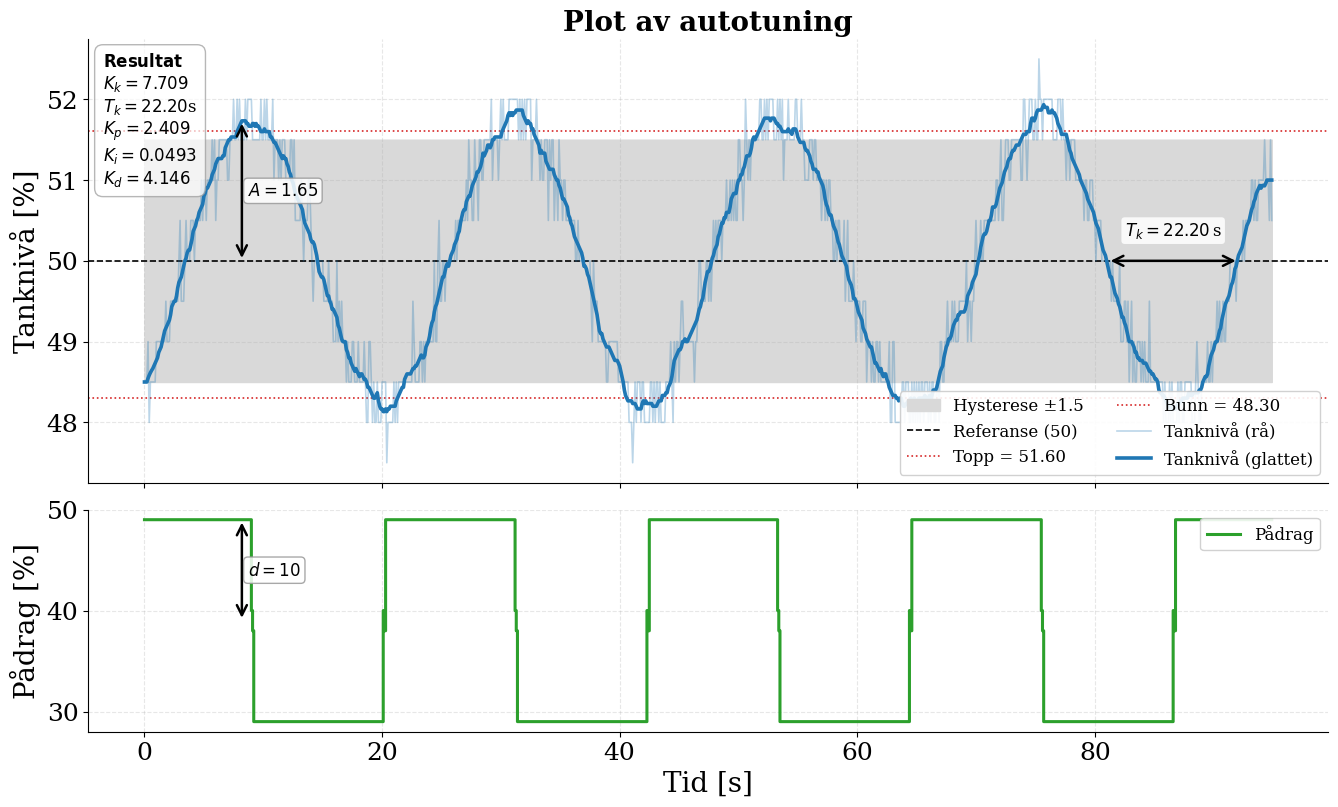

Lagret: autotuning_rapport.pdf og autotuning_rapport.png


In [13]:
# =============================================================
#  RELAY-AUTOTUNING – KOMPLETT ANALYSE + RAPPORT-PLOT
#  Etterligner PLC-logikk fra slave.pdf:
#    - fPeakHigh/Low = globale max/min over autotune-vindu
#    - fTk = 2 × MEDIAN halvperiode (robust mot edge-effekter)
#    - Kp = Kk/3.2,  Ki = Kp/(2.2·Tk),  Kd = Kp·Tk/Td_div
# =============================================================
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- INNSTILLINGER -------------------------------------
filnavn        = "autotuning"
CSV_FIL        = f"{filnavn}.csv"
start_tid      = 0          # s
slutt_tid      = 95         # s
iRef           = 50         # %
fHyst          = 1.5        # %
fRelayD        = 10.0       # PLC-konstant (relay-halvamplitude d)
smooth_window  = 15
peak_trim      = 0.10
Td_div         = 12.9
metode_navn    = "Tyreus-Luyben (PLC-tilpasset)"

# ---------- 1) LAST DATA --------------------------------------
df = pd.read_csv(CSV_FIL)
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()
df["tid_s"] = (df["tid_s"]
               + df.groupby("tid_s").cumcount()
               / df.groupby("tid_s")["tid_s"].transform("count"))

df["tank_smooth"] = (df["tank"]
                     .rolling(smooth_window, center=True, min_periods=1).mean())

mask = (df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)
d    = df.loc[mask].reset_index(drop=True)

# ---------- 2) RELAY-NIVÅER -----------------------------------
pad_sorted = np.sort(d["pådrag"].values)
relay_on   = pad_sorted[-1]
relay_off  = pad_sorted[0]
fNomPadrag = (relay_on + relay_off) / 2.0

# ---------- 3) GLOBALE PEAKS ----------------------------------
hi = np.quantile(d["tank_smooth"].dropna(), 1.0 - peak_trim)
lo = np.quantile(d["tank_smooth"].dropna(),       peak_trim)
fPeakHigh  = float(hi)
fPeakLow   = float(lo)
fAmplitude = (fPeakHigh - fPeakLow) / 2.0

# ---------- 4) PERIODE: zero-crossings ------------------------
d["fError"] = iRef - d["tank_smooth"]
sign_change = np.sign(d["fError"]) != np.sign(d["fError"].shift(1))
zc          = d.index[sign_change & d["fError"].notna()].tolist()
zc_t        = [float(d["tid_s"].iloc[i]) for i in zc]

half_periods = np.diff(zc_t)
half_periods = half_periods[half_periods > 1.0]
if len(half_periods) < 2:
    raise RuntimeError("For få halvperioder etter trimming.")

fHalfPeriod = float(np.median(half_periods))
fTk         = 2.0 * fHalfPeriod
Tk          = fTk

# ---------- 5) PID-PARAMETRE ----------------------------------
Kk = (4.0 * fRelayD) / (np.pi * fAmplitude)
Kp = Kk / 3.2
Ki = Kp / (2.2 * Tk)
Td = Tk / Td_div
Kd = Kp * Td

print(f"fPeakHigh = {fPeakHigh:.3f}   fPeakLow = {fPeakLow:.3f}   "
      f"A = {fAmplitude:.3f}   d = {fRelayD:.1f}")
print(f"Kk = 4d/(πA) = {Kk:.3f}   Tk = {Tk:.2f} s")
print(f"[{metode_navn}]  Kp = {Kp:.3f}   Ki = {Ki:.4f}   Kd = {Kd:.3f}")
print(f"Mål fra PLC:                       Kp = 2.410   Ki = 0.0500   Kd = 4.080")

# ---------- 6) RAPPORT-PLOT ----------------------------------
mpl.rcParams.update({
    "font.family":       "serif",
    "font.size":         18,
    "axes.titlesize":    20,
    "axes.labelsize":    20,
    "legend.fontsize":   12,
    "xtick.labelsize":   18,
    "ytick.labelsize":   18,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":   2.0,
})

t      = d["tid_s"].values
tank   = d["tank"].values
tank_s = d["tank_smooth"].values
padrag = d["pådrag"].values

GRONN = "tab:green"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

# === Panel 1: tanknivå =======================================
ax1.fill_between(t, iRef-fHyst, iRef+fHyst,
                 color="0.85", label=f"Hysterese ±{fHyst}")
ax1.axhline(iRef,      color="k",       lw=1.2, ls="--", label=f"Referanse ({iRef})")
ax1.axhline(fPeakHigh, color="tab:red", lw=1.2, ls=":",  label=f"Topp = {fPeakHigh:.2f}")
ax1.axhline(fPeakLow,  color="tab:red", lw=1.2, ls=":",  label=f"Bunn = {fPeakLow:.2f}")
ax1.plot(t, tank,   color="tab:blue", alpha=0.30, lw=1.2, label="Tanknivå (rå)")
ax1.plot(t, tank_s, color="tab:blue", lw=2.6,            label="Tanknivå (glattet)")

# Tk-pil PÅ y = iRef, mellom to like-rettede zero-crossings (1 hel periode)
if len(zc_t) >= 3:
    ta = zc_t[-3]
    tb = zc_t[-1]
    ax1.annotate("", xy=(tb, iRef), xytext=(ta, iRef),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=1.8))
    ax1.text((ta+tb)/2, iRef + 0.25, fr"$T_k = {Tk:.2f}\,$s",
             ha="center", va="bottom", fontsize=12,
             bbox=dict(boxstyle="round,pad=0.2",
                       facecolor="white", edgecolor="none", alpha=0.85))

# A-pil: fra iRef opp til FAKTISK topp av en bølge (ikke trim-linja)
# Finn første halvperiode der tank stiger over iRef
for i in range(len(zc) - 1):
    seg = d["tank_smooth"].iloc[zc[i]:zc[i+1] + 1]
    if seg.max() > iRef + 0.5:                        # positiv halvperiode
        idx_topp = seg.idxmax()
        x_topp   = float(d["tid_s"].iloc[idx_topp])
        y_topp   = float(d["tank_smooth"].iloc[idx_topp])
        ax1.annotate("", xy=(x_topp, y_topp), xytext=(x_topp, iRef),
                     arrowprops=dict(arrowstyle="<->", color="black", lw=1.8))
        ax1.text(x_topp + 0.5, (iRef + y_topp) / 2,
                 fr"$A = {fAmplitude:.2f}$",
                 ha="left", va="center", fontsize=12,
                 bbox=dict(boxstyle="round,pad=0.25",
                           facecolor="white", edgecolor="0.6", alpha=0.85))
        x_dpil = x_topp                                # juster d-pil til samme x
        break
else:
    x_dpil = zc_t[0] + Tk / 4.0

ax1.set_ylabel("Tanknivå [%]")
ax1.set_title("Plot av autotuning", weight="bold")
ax1.legend(loc="lower right", ncol=2, framealpha=0.9)

# Resultatboks
boks = (
    r"$\bf{Resultat}$"
    f"\n$K_k = {Kk:.3f}$"
    f"\n$T_k = {Tk:.2f}$s"
    f"\n$K_p = {Kp:.3f}$"
    f"\n$K_i = {Ki:.4f}$"
    f"\n$K_d = {Kd:.3f}$"
)
ax1.text(0.012, 0.97, boks, transform=ax1.transAxes,
         ha="left", va="top", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5",
                   facecolor="white", edgecolor="0.6", alpha=0.7))

# === Panel 2: relay-pådrag (grønn) ===========================
ax2.step(t, padrag, where="post", color=GRONN, lw=2.2, label="Pådrag")

# d-pil: relay-halvamplitude fra nominell opp til ON-nivå
ax2.annotate("", xy=(x_dpil, relay_on), xytext=(x_dpil, fNomPadrag),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.8))
ax2.text(x_dpil + 0.5, (fNomPadrag + relay_on) / 2,
         fr"$d = {fRelayD:.0f}$",
         ha="left", va="center", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.25",
                   facecolor="white", edgecolor="0.6", alpha=0.85))

ax2.set_xlabel("Tid [s]")
ax2.set_ylabel("Pådrag [%]")
ax2.legend(loc="upper right", ncol=3, framealpha=0.9)
ax2.margins(x=0)

plt.tight_layout()
out = f"{filnavn}_rapport"
plt.savefig(f"{out}.pdf", bbox_inches="tight")
plt.savefig(f"{out}.png", bbox_inches="tight", dpi=300)
plt.show()
print(f"Lagret: {out}.pdf og {out}.png")


In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- STIL ----------
mpl.rcParams.update({
    "font.family":       "serif",
    "font.size":         18,
    "axes.titlesize":    20,
    "axes.labelsize":    20,
    "legend.fontsize":   14,
    "xtick.labelsize":   18,
    "ytick.labelsize":   18,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":   2.0,
})

# ---------- DATA ----------
t_start  = 0.2          # når overgangen starter
t_slutt  = 1.2          # når overgangen er ferdig (lengde 1.0)
t_total  = 1.5          # totallengde på plottet

t   = np.linspace(0, t_total, 400)

# Lineær rampe: 0 før, lineær mellom, 1 etter
linear = np.clip((t - t_start) / (t_slutt - t_start), 0.0, 1.0)

# Smoothstep: 0 før, 3x²-2x³ mellom, 1 etter
x          = np.clip((t - t_start) / (t_slutt - t_start), 0.0, 1.0)
smoothstep = 3*x**2 - 2*x**3

# Steg: 0 før t_start, vertikalt opp, 1 etter
t_steg = np.array([0.0,  t_start, t_start, t_total])
y_steg = np.array([0.0,  0.0,     1.0,     1.0])

# ---------- PLOT ----------
fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(t_steg, y_steg, color="tab:green", ls="-.", lw=2.2, label="Steg")
ax.plot(t, linear,      color="tab:red",   ls="--", lw=2.2, label="Lineær rampe")
ax.plot(t, smoothstep,  color="tab:blue",           lw=2.6, label=r"Smoothstep $3t^2 - 2t^3$")

ax.axvline(t_start, color="0.6", lw=1.0, ls=":")

ax.set_xlabel(r"Tid $t$")
ax.set_ylabel(r"Utgangsverdi $f(t)$")
ax.set_title("Steg, lineær rampe og smoothstep", weight="bold")
ax.legend(loc="lower right", framealpha=0.9)
ax.margins(x=0)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("smoothstep.pdf", bbox_inches="tight")
plt.savefig("smoothstep.png", bbox_inches="tight", dpi=300)
plt.show()


/tmp/ipykernel_52575/588217251.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


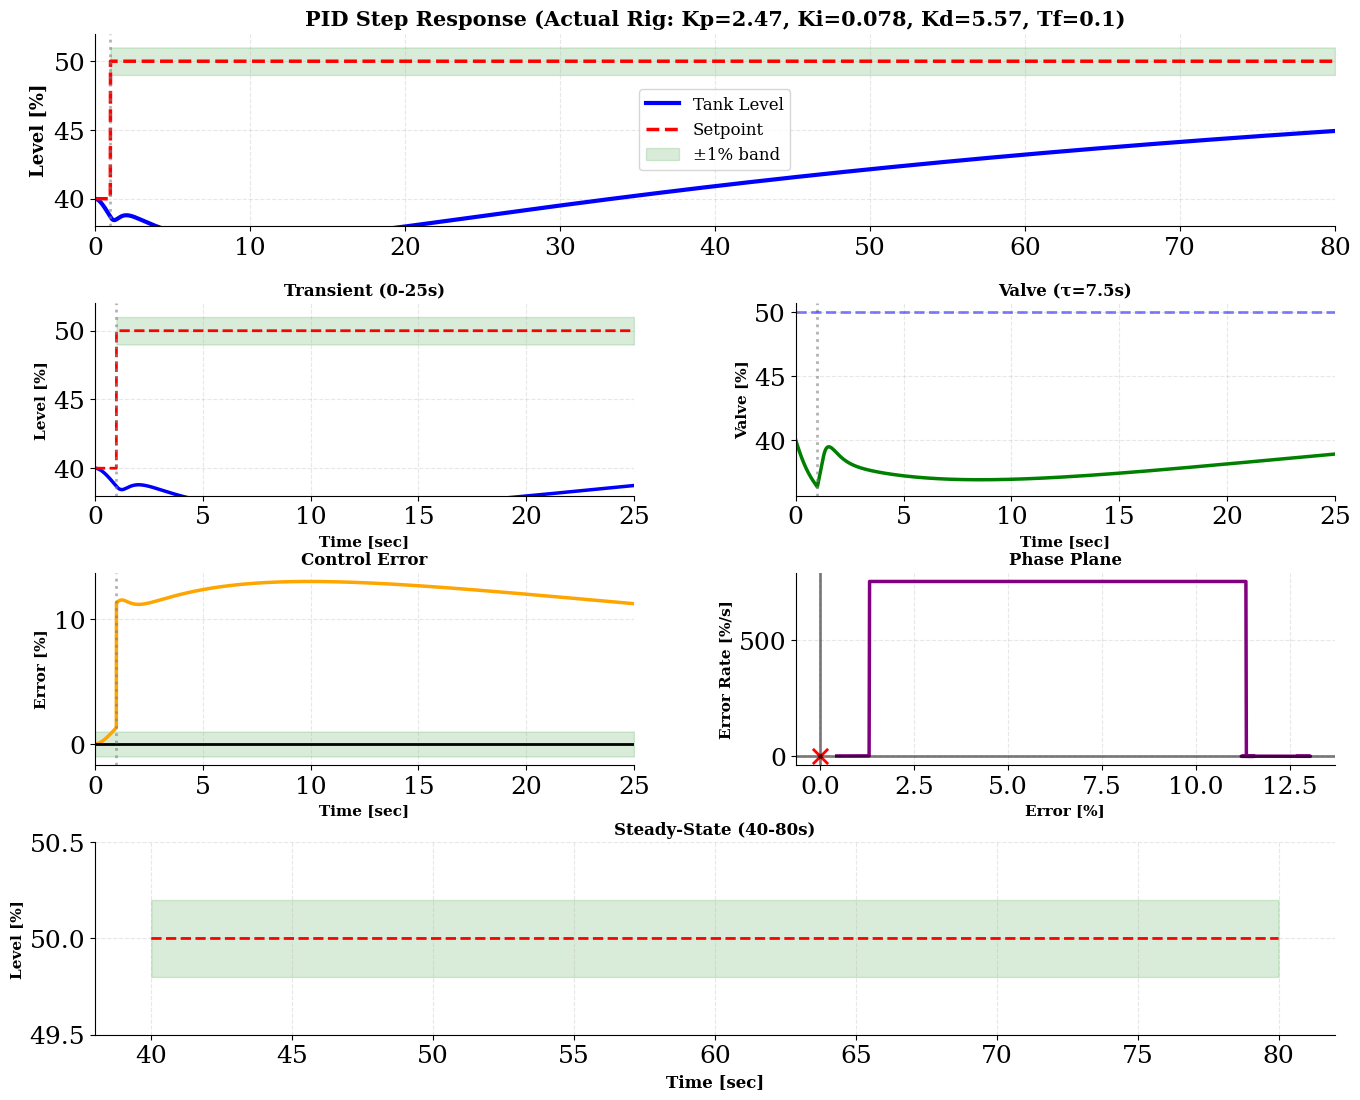


PID Step Response Complete


In [23]:
# PID Step Response with Actual Rig Parameters
# Kp=2.47, Ki=0.078, Kd=5.57, Tf=0.1
# Tank tau = 1.2 sec, Valve tau = 7.5 sec

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

class PIDController:
    def __init__(self, Kp=2.47, Ki=0.078, Kd=5.57, Tf=0.1):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.Tf = Tf
        self.int_err = 0.0
        self.filt_deriv = 0.0
        self.prev_err = 0.0
        
    def update(self, error, dt):
        p = self.Kp * error
        self.int_err += error * dt
        i = self.Ki * self.int_err
        
        if dt > 0:
            raw_d = (error - self.prev_err) / dt
            self.filt_deriv += (raw_d - self.filt_deriv) * dt / (self.Tf + dt)
            d = self.Kd * self.filt_deriv
        else:
            d = 0
        
        self.prev_err = error
        u = p + i + d
        
        if u < 0 or u > 100:
            self.int_err -= error * dt
        
        return np.clip(u, 0, 100)

def system(t, y, pid_ctrl, setpoint_func):
    h, v = y
    setpoint = setpoint_func(t)
    error = setpoint - h
    u = pid_ctrl.update(error, 0.001)
    
    dh_dt = (v - h) / 1.2  # Tank tau = 1.2 sec
    dv_dt = (u - v) / 7.5  # Valve tau = 7.5 sec
    
    return [dh_dt, dv_dt]

def setpoint(t):
    return 40.0 if t < 1.0 else 50.0

pid = PIDController(Kp=2.47, Ki=0.078, Kd=5.57, Tf=0.1)
t_eval = np.linspace(0, 80, 12000)
y0 = [40.0, 40.0]

sol = solve_ivp(system, (0, 80), y0, args=(pid, setpoint),
                 method='RK45', t_eval=t_eval, dense_output=True,
                 rtol=1e-6, atol=1e-8, max_step=0.01)

t = sol.t
h = sol.y[0]
v = sol.y[1]
sp = np.array([setpoint(ti) for ti in t])

# Create plot
fig = plt.figure(figsize=(16, 13))
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

ax = fig.add_subplot(gs[0, :])
ax.plot(t, h, 'b-', linewidth=3, label='Tank Level')
ax.plot(t, sp, 'r--', linewidth=2.5, label='Setpoint')
ax.axvline(x=1, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax.fill_between(t[t >= 1], 49, 51, alpha=0.15, color='green', label='±1% band')
ax.set_ylabel('Level [%]', fontsize=13, fontweight='bold')
ax.set_title('PID Step Response (Actual Rig: Kp=2.47, Ki=0.078, Kd=5.57, Tf=0.1)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_xlim([0, 80])
ax.set_ylim([38, 52])

m = t <= 25
ax = fig.add_subplot(gs[1, 0])
ax.plot(t[m], h[m], 'b-', linewidth=2.5)
ax.plot(t[m], sp[m], 'r--', linewidth=2)
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.6)
ax.fill_between(t[m][t[m] >= 1], 49, 51, alpha=0.15, color='green')
ax.set_ylabel('Level [%]', fontsize=11, fontweight='bold')
ax.set_xlabel('Time [sec]', fontsize=11, fontweight='bold')
ax.set_title('Transient (0-25s)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 25])
ax.set_ylim([38, 52])

ax = fig.add_subplot(gs[1, 1])
ax.plot(t[m], v[m], 'g-', linewidth=2.5)
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.6)
ax.axhline(y=50, color='blue', linestyle='--', alpha=0.5)
ax.set_ylabel('Valve [%]', fontsize=11, fontweight='bold')
ax.set_xlabel('Time [sec]', fontsize=11, fontweight='bold')
ax.set_title('Valve (τ=7.5s)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 25])

err = sp - h
ax = fig.add_subplot(gs[2, 0])
ax.plot(t[m], err[m], 'orange', linewidth=2.5)
ax.axhline(y=0, color='black', linestyle='-')
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.6)
ax.fill_between(t[m], -1, 1, alpha=0.15, color='green')
ax.set_ylabel('Error [%]', fontsize=11, fontweight='bold')
ax.set_xlabel('Time [sec]', fontsize=11, fontweight='bold')
ax.set_title('Control Error', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 25])

m_early = (t >= 0.5) & (t <= 15)
de_dt = np.gradient(err, t)
ax = fig.add_subplot(gs[2, 1])
ax.plot(err[m_early], de_dt[m_early], 'purple', linewidth=2.5)
ax.scatter([0], [0], color='red', s=120, marker='x')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Error [%]', fontsize=11, fontweight='bold')
ax.set_ylabel('Error Rate [%/s]', fontsize=11, fontweight='bold')
ax.set_title('Phase Plane', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

m_ss = (t >= 40) & (t <= 80)
ax = fig.add_subplot(gs[3, :])
ax.plot(t[m_ss], h[m_ss], 'b-', linewidth=2.5)
ax.plot(t[m_ss], sp[m_ss], 'r--', linewidth=2)
ax.fill_between(t[m_ss], 49.8, 50.2, alpha=0.15, color='green')
ax.set_xlabel('Time [sec]', fontsize=12, fontweight='bold')
ax.set_ylabel('Level [%]', fontsize=11, fontweight='bold')
ax.set_title('Steady-State (40-80s)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([49.5, 50.5])

plt.tight_layout()
plt.show()

print('\nPID Step Response Complete')
